<a href="https://colab.research.google.com/github/ziadm8692-glitch/Data-Analysis-and-AI--Portfolio/blob/main/Diabetes_Risk_Prediction_Dataset_(50K_patients).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/diabetes_risk_prediction_dataset.csv")
df.head(10)

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High
5,6,29.0,Male,Bangladesh,153.3,86.3,36.7,77.1,142.2,5.0,...,Yes,Yes,Poor,Retired,Urban,4.4,69,Consult Endocrinologist Immediately,Yes,High
6,7,90.0,Other,Germany,160.8,67.2,26.0,113.6,126.6,6.6,...,Yes,No,Poor,Retired,Urban,4.8,68,Begin Diabetes Management Plan,Yes,High
7,8,80.0,Female,Bangladesh,190.3,116.9,32.3,67.4,146.2,6.7,...,Yes,No,Average,Government,Urban,4.6,80,Begin Diabetes Management Plan,Yes,High
8,9,40.0,Female,United States,146.2,107.6,50.3,86.6,237.5,10.9,...,No,No,Poor,Business,Rural,3.7,79,Medical Evaluation Required,Yes,High
9,10,73.0,Other,Malaysia,194.2,54.8,14.5,132.0,104.2,4.9,...,No,Yes,Good,Business,Rural,3.7,63,Weight Management Program,Yes,Moderate


In [3]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


# ***Data Cleaing***

In [4]:
df.isna().sum()

,0
Patient_ID,0
Age,497
Gender,0
Country,0
Height_cm,2945
Weight_kg,2962
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,959
HbA1c,1974


In [5]:
num_cols = [
    'Height_cm', 'Weight_kg', 'Sleep_Hours', 'Exercise_Hours_Per_Week',
    'Age', 'Daily_Walking_Minutes', 'LDL', 'HDL', 'Blood_Glucose',
    'HbA1c', 'Total_Cholesterol', 'Triglycerides'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = ['Physical_Activity_Level', 'Medication_Adherence']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
df['Daily_Walking_Minutes']

,Daily_Walking_Minutes
0,106.1
1,96.1
2,68.7
3,23.1
4,131.2
...,...
49995,39.5
49996,80.9
49997,106.8
49998,62.2


In [7]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
Country,0
Height_cm,0
Weight_kg,0
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,0
HbA1c,0


In [8]:
df.duplicated().sum()

np.int64(0)

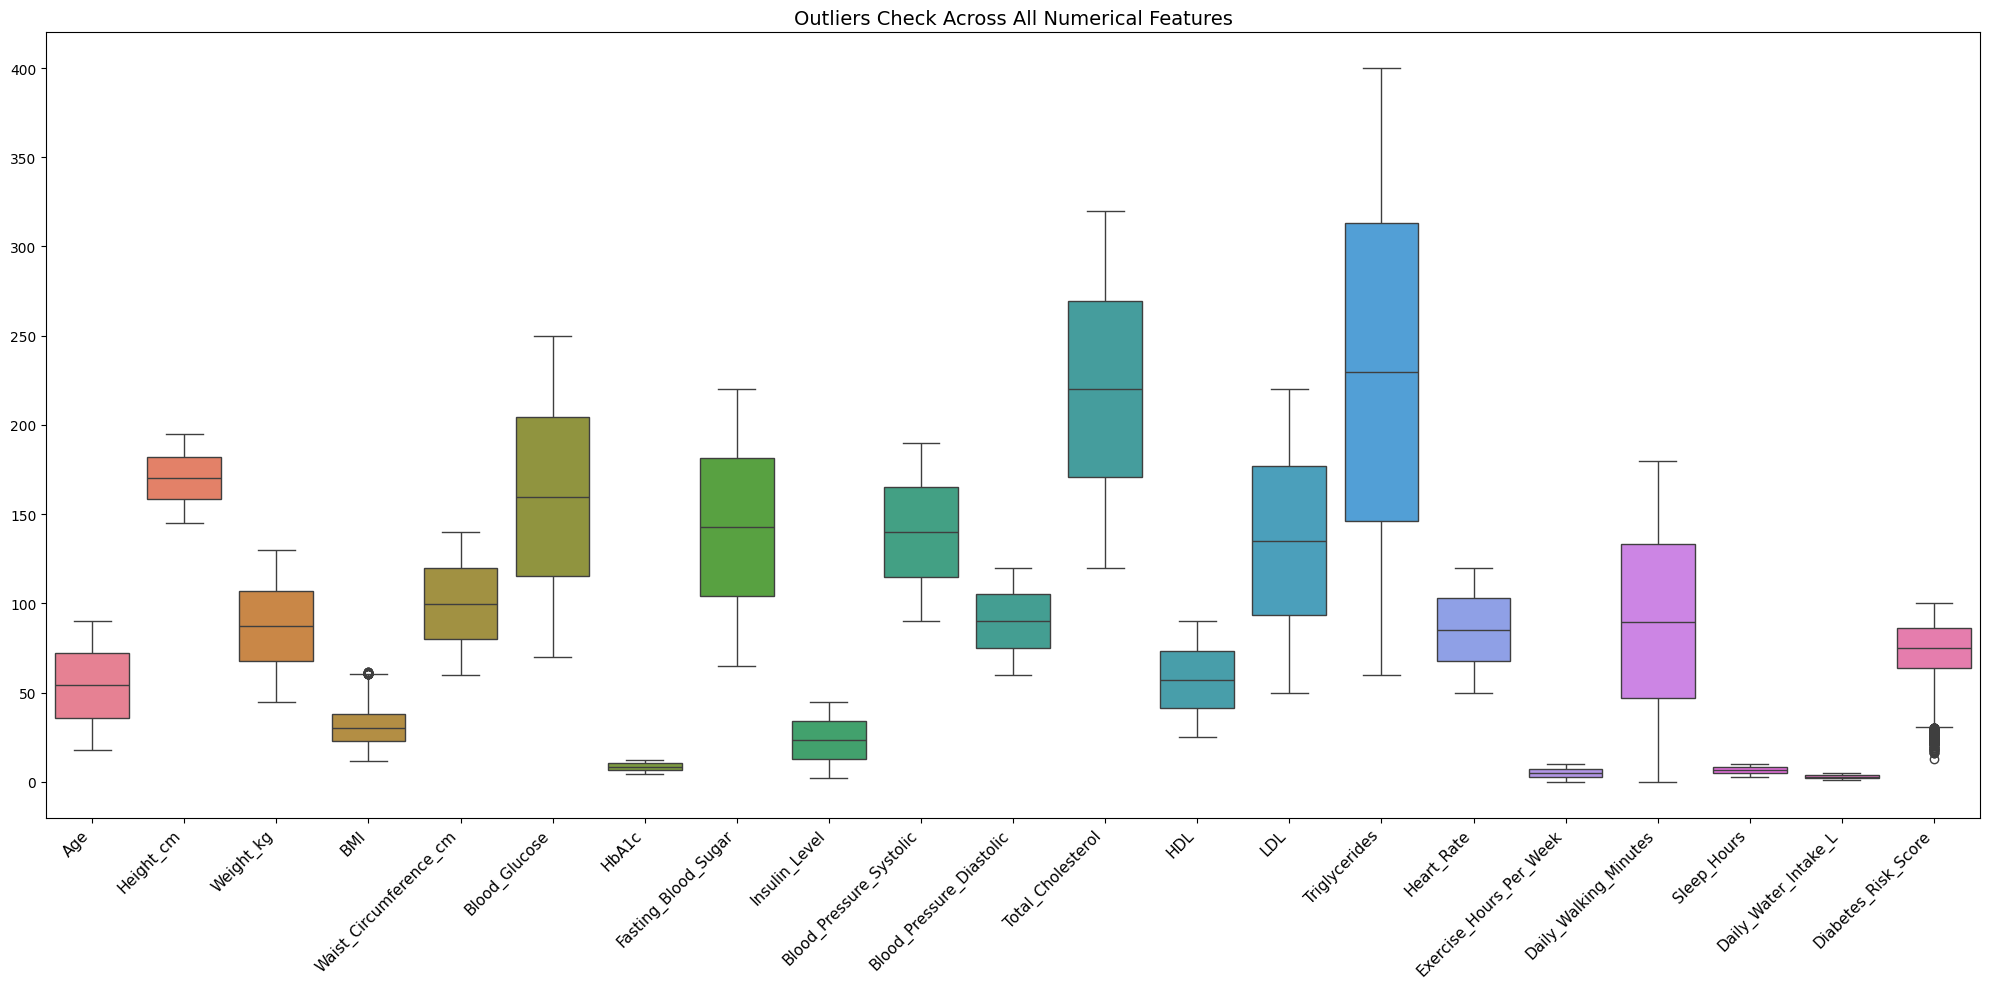

In [14]:
plt.figure(figsize=(20,10))
sns.boxplot(df[[
    'Age',
    'Height_cm',
    'Weight_kg',
    'BMI',
    'Waist_Circumference_cm',
    'Blood_Glucose',
    'HbA1c',
    'Fasting_Blood_Sugar',
    'Insulin_Level',
    'Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic',
    'Total_Cholesterol',
    'HDL',
    'LDL',
    'Triglycerides',
    'Heart_Rate',
    'Exercise_Hours_Per_Week',
    'Daily_Walking_Minutes',
    'Sleep_Hours',
    'Daily_Water_Intake_L',
    'Diabetes_Risk_Score'
]])
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title("Outliers Check Across All Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

# ***EDA***

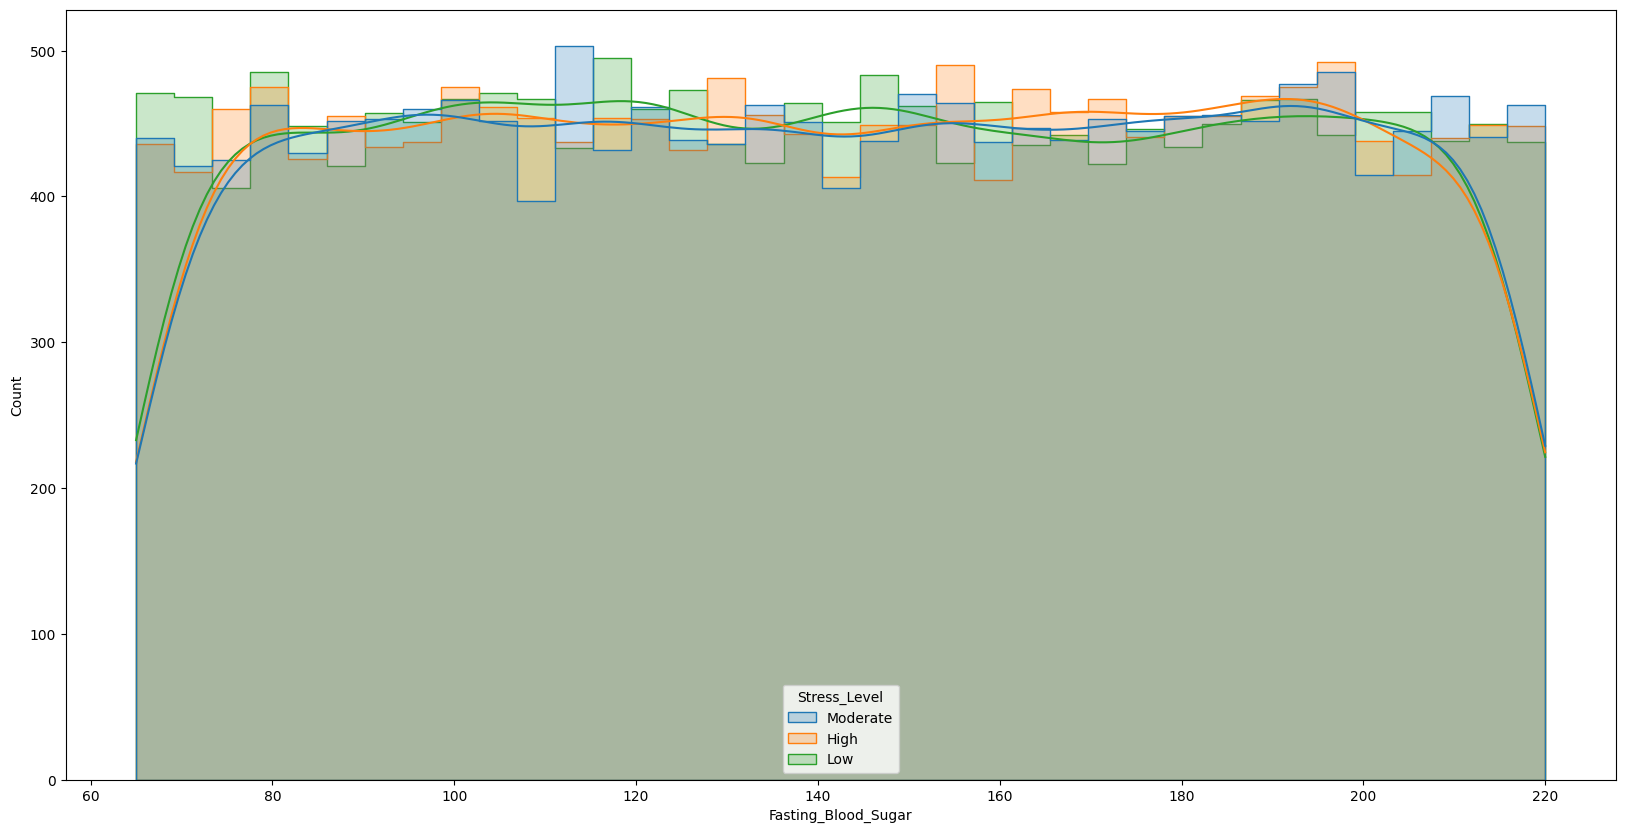

In [19]:
plt.figure(figsize=(20,10))
sns.histplot(x="Fasting_Blood_Sugar", hue="Stress_Level", data=df,kde=True,element="step")
plt.show()
#

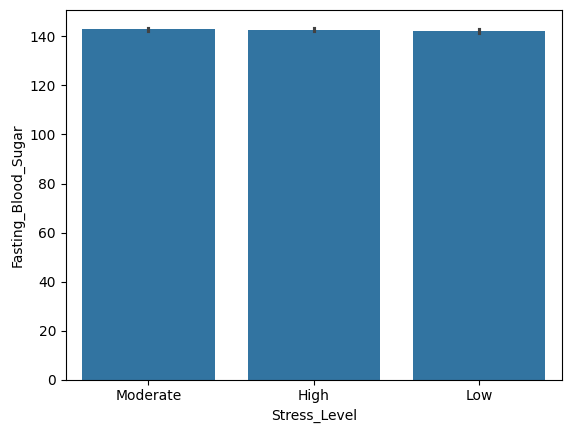

In [20]:
sns.barplot(x="Stress_Level", y="Fasting_Blood_Sugar", data=df)
plt.show()
#

In [26]:
def BMI_Level(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25.0:
        return "Normal"
    elif bmi < 30.0:
        return "Overweight"
    else:
        return "Obese"

df['BMI_Level'] = df['BMI'].apply(BMI_Level)

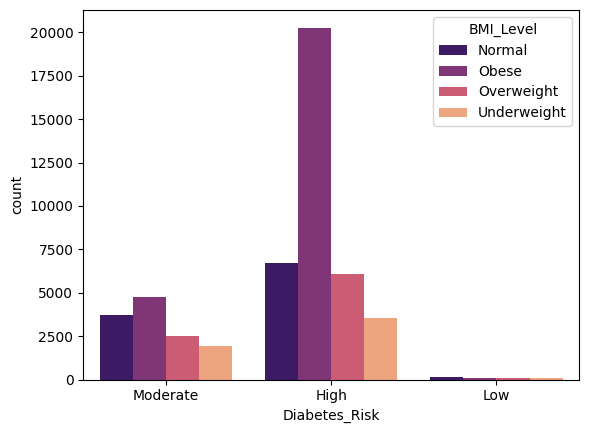

In [27]:
sns.countplot(x="Diabetes_Risk",hue="BMI_Level",data=df, palette='magma')


plt.show()
#

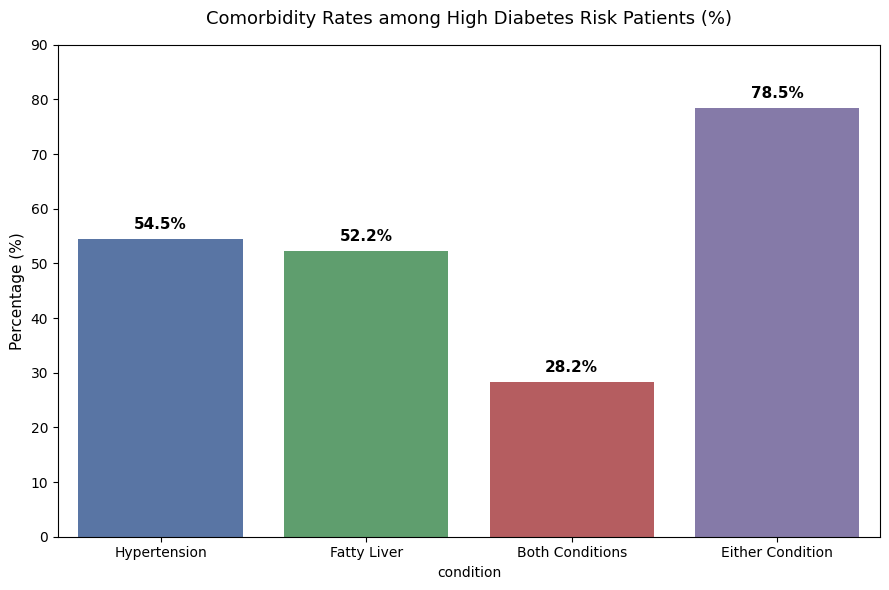

In [33]:
high_risk=df[df['Diabetes_Risk']=="High"]
ht_pct = (high_risk['Hypertension']=='Yes').mean()*100
fl_pct = (high_risk['Fatty_Liver']=='Yes').mean()*100
both_pct = ((high_risk['Hypertension']=='Yes') & (high_risk['Fatty_Liver']=='Yes')).mean()*100
either_pct = ((high_risk['Hypertension']=='Yes') | (high_risk['Fatty_Liver']=='Yes')).mean()*100

plot_data=pd.DataFrame({'condition':['Hypertension',
        'Fatty Liver',
        'Both Conditions',
        'Either Condition'],'percentage':[ht_pct,fl_pct,both_pct,either_pct]}
                       )
plt.figure(figsize=(9,6))
colors=['#4c72b0','#55a868','#c44e52','#8172b0']
ax=sns.barplot(x='condition', y='percentage', hue='condition', data=plot_data, palette=colors, legend=False)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Comorbidity Rates among High Diabetes Risk Patients (%)', fontsize=13, pad=15)
plt.ylabel('Percentage (%)', fontsize=11)
plt.ylim(0, 90)

plt.tight_layout()
plt.show()

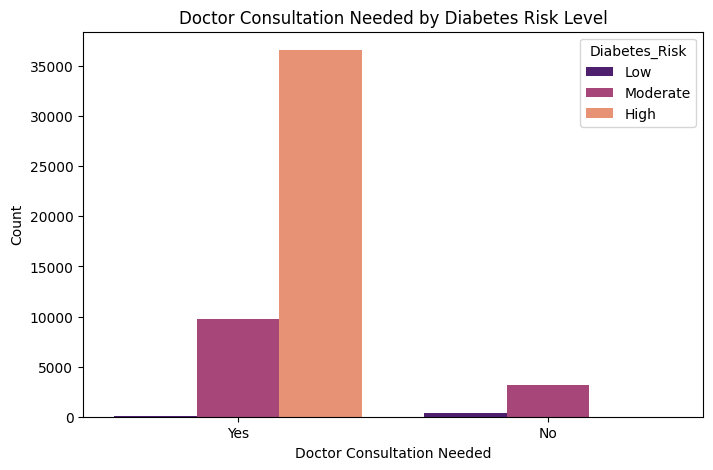

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(
    x="Doctor_Consultation_Needed",
    hue="Diabetes_Risk",
    data=df,
    palette='magma',
    hue_order=['Low', 'Moderate', 'High']
)

plt.title("Doctor Consultation Needed by Diabetes Risk Level")
plt.xlabel("Doctor Consultation Needed")
plt.ylabel("Count")
plt.show()

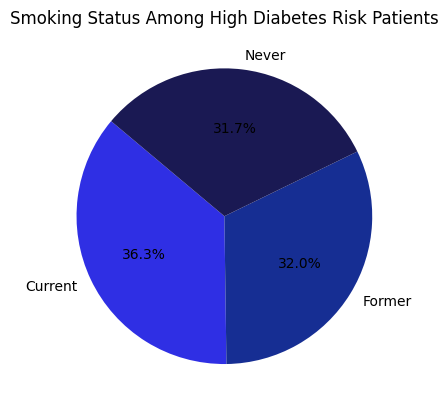

In [42]:
smoking_risk=df[df['Diabetes_Risk']=="High"]['Smoking_Status'].value_counts(normalize=True)*100
plt.pie(smoking_risk,labels=smoking_risk.index,autopct='%1.1f%%',startangle=140, colors=['#2F2FE4', '#162E93','#1A1953'])
plt.title('Smoking Status Among High Diabetes Risk Patients')
plt.show()
#

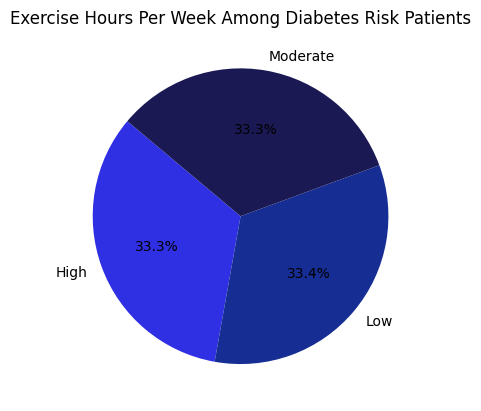

In [43]:
lifestyle_kpi=df.groupby('Diabetes_Risk')['Exercise_Hours_Per_Week'].mean()
plt.pie(lifestyle_kpi,labels=lifestyle_kpi.index,autopct='%1.1f%%',startangle=140, colors=['#2F2FE4', '#162E93','#1A1953'])
plt.title('Exercise Hours Per Week Among Diabetes Risk Patients')
plt.show()
#

In [44]:
waist_kpi=(high_risk['Waist_Circumference_cm']>90).mean()*100
print(f"High Waist Circumference Rate: {waist_kpi:.1f}%")

High Waist Circumference Rate: 62.5%


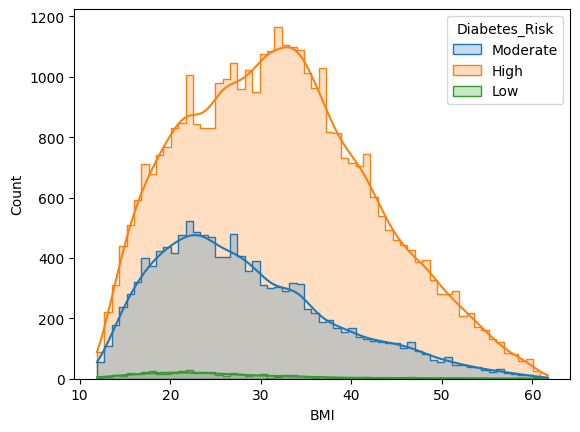

In [50]:
sns.histplot(x='BMI',data=df , hue ='Diabetes_Risk', kde=True, element='step')
plt.show()
#

# ***ML***

In [64]:
df_final=df.drop(columns=['Patient_ID','AI_Health_Recommendation',])

In [65]:
X=df_final.drop(columns=['Diabetes_Risk'])
Y=df_final['Diabetes_Risk']

In [66]:
from sklearn.model_selection import  train_test_split
X_train,X_test,Y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [67]:
categorical_cols = [
    'Doctor_Consultation_Needed', 'Residence_Type', 'Work_Type',
    'Medication_Adherence', 'PCOS', 'Fatty_Liver', 'Heart_Disease',
    'Hypertension', 'Family_History_Diabetes', 'Alcohol_Consumption',
    'Smoking_Status', 'Stress_Level', 'Sugar_Intake_Level', 'Diet_Quality',
    'Gender', 'Country', 'BMI_Level'
]

In [70]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

In [71]:
from sklearn.ensemble import  RandomForestClassifier
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

y_pred = rf_model.predict(X_test)

print("🎯 Accuracy Score:", accuracy_score(Y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(Y_test, y_pred))

🎯 Accuracy Score: 0.9997

📊 Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00      7304
         Low       1.00      0.96      0.98        82
    Moderate       1.00      1.00      1.00      2614

    accuracy                           1.00     10000
   macro avg       1.00      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000



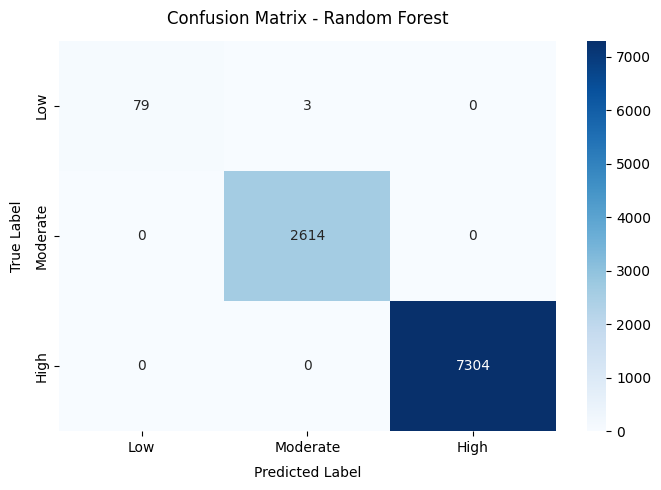

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ['Low', 'Moderate', 'High']

cm = confusion_matrix(Y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)

plt.title('Confusion Matrix - Random Forest', fontsize=12, pad=12)
plt.xlabel('Predicted Label', fontsize=10, labelpad=8)
plt.ylabel('True Label', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()